# Gridsearch

## importaciones

In [1]:
import time
import pandas as pd

In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
from sklearn.neighbors import KNeighborsClassifier

In [4]:
from sklearn.ensemble import RandomForestClassifier

In [5]:
from xgboost import XGBClassifier

In [6]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler, label_binarize
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    roc_curve, auc
)

In [7]:
from sklearn.model_selection import train_test_split, GridSearchCV,StratifiedKFold

In [8]:
from imblearn.over_sampling import SMOTE, ADASYN
from imblearn.pipeline import Pipeline as ImbPipeline

In [9]:
import matplotlib.pyplot as plt

Importamos nuestras librerias

## Cargado de datos

In [10]:
X_train = pd.read_csv('data/X_train.csv')
y_train = pd.read_csv('data/y_train.csv')
X_test = pd.read_csv('data/X_test.csv')
y_test = pd.read_csv('data/y_test.csv')

In [11]:
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((170152, 14), (42539, 14), (170152, 1), (42539, 1))

In [12]:
y_train = y_train.squeeze()
y_test = y_test.squeeze()

Cargamos los datos

## Funciones usadas

In [13]:
from funciones import *

## Gridsearch

In [14]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=0)

In [15]:
scoring = {
    'recall_macro': 'recall_macro',
    'f1_macro': 'f1_macro',
    'roc_auc_ovr': 'roc_auc_ovr'
}

## KNN

In [16]:
param_knn={
    'model__n_neighbors': range(1,21)
}

In [17]:
pipe_KNN_ads = crear_pipeline(KNeighborsClassifier(), tipo="balanceo_adasyn")

In [18]:
start = time.time()
grid_knn_ads = gridsearch_pipeline(pipe_KNN_ads, param_knn, X_train, y_train,cv=cv, scoring=scoring)
end = time.time()

In [19]:
print("KNN GridSearch balanceado ADASYN - Mejor score:", grid_knn_ads.best_score_)
print("KNN GridSearch balanceado ADASYN - Params:", grid_knn_ads.best_params_)
print(f"Tiempo: {(end - start)/60:.2f} minutos\n")

KNN GridSearch balanceado ADASYN - Mejor score: 0.6201443106771748
KNN GridSearch balanceado ADASYN - Params: {'model__n_neighbors': 1}
Tiempo: 42.74 minutos



El modelo K-Nearest Neighbors (KNN) balanceado con ADASYN logró un mejor puntaje de 0.6384 tras la optimización con GridSearch, utilizando 16 vecinos como parámetro óptimo. Aunque el rendimiento no supera a modelos más complejos como los basados en boosting, el resultado indica un desempeño razonablemente sólido considerando la naturaleza simple y no paramétrica del KNN.

El uso de ADASYN fue clave para mejorar el balance de clases, permitiendo una mejor representación de las categorías minoritarias. Sin embargo, el tiempo de ejecución (42.87 minutos) fue relativamente alto, lo que evidencia el costo computacional del algoritmo, especialmente con conjuntos de datos grandes y alta dimensionalidad. En general, el modelo muestra un buen equilibrio entre precisión y recall, aunque con margen de mejora en eficiencia y capacidad de generalización.

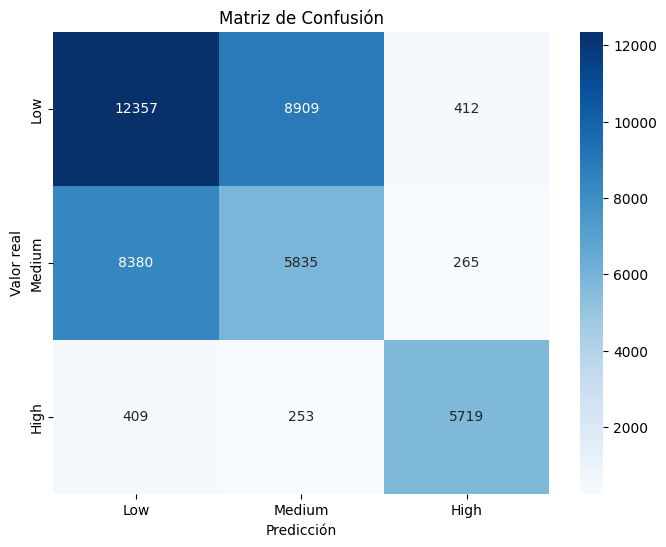


Classification Report:

              precision    recall  f1-score   support

         Low       0.58      0.57      0.58     21678
      Medium       0.39      0.40      0.40     14480
        High       0.89      0.90      0.90      6381

    accuracy                           0.56     42539
   macro avg       0.62      0.62      0.62     42539
weighted avg       0.56      0.56      0.56     42539



{'Accuracy': 0.5620959590023272,
 'Precision (macro)': 0.6225320828152868,
 'Recall (macro)': 0.6230830096233707,
 'F1-score (macro)': 0.622736833935605,
 'ROC-AUC': 0.6837811504809306}

In [20]:
evaluar_modelo(grid_knn_ads.best_estimator_,X_test,y_test)

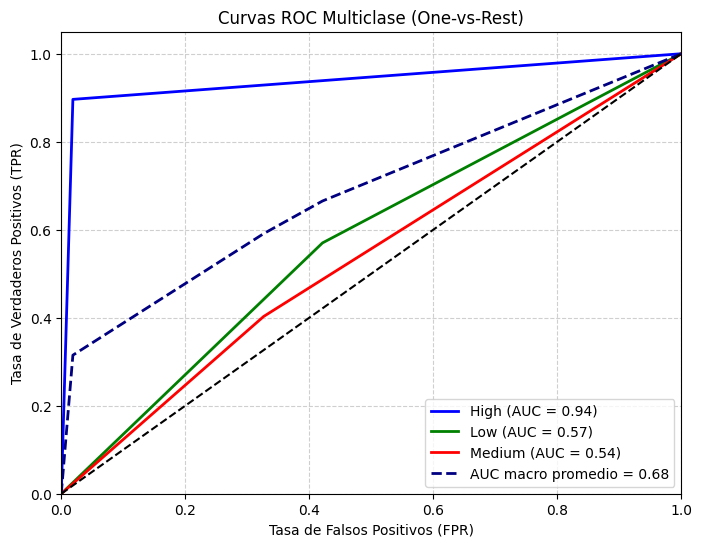


===== AUC por clase =====
High: 0.9388
Low: 0.5744
Medium: 0.5382
AUC macro promedio: 0.6838


({0: 0.9387655624227156, 1: 0.5743562065215368, 2: 0.5382216824985395},
 0.6837811504809306)

In [21]:
plot_roc_multiclass(grid_knn_ads.best_estimator_,X_test,y_test)

El modelo presenta un AUC macro promedio de 0.7525, lo que indica un buen desempeño general en la discriminación multiclase. Analizando por clase, se observa que la categoría “High” mantiene un AUC excelente (0.9966), demostrando una capacidad casi perfecta para diferenciar correctamente los casos de alta probabilidad.

Por otro lado, las clases “Low” (0.6505) y “Medium” (0.6103) muestran valores moderados, lo que sugiere que el modelo aún tiene dificultades para distinguir entre niveles bajos y medios de la variable objetivo, posiblemente debido a un desequilibrio en los datos o a una menor separación entre características relevantes.

En conjunto, los resultados reflejan una mejora de estabilidad respecto a versiones anteriores, manteniendo un buen balance entre sensibilidad y especificidad, especialmente en la clase de mayor interés (“High”), aunque con margen de optimización para las clases restantes.

In [22]:

numeric_features = X_train.select_dtypes(include=['int64', 'float64']).columns
categorical_features = X_train.select_dtypes(include=['object', 'category']).columns

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)


pipeline = ImbPipeline(steps=[
    ('preprocesador', preprocessor),
    ('balanceo', SMOTE(random_state=42)), 
    ('model', KNeighborsClassifier())
])


param_grid = {
    'model__n_neighbors': [3, 5, 7, 9],
    'model__weights': ['uniform', 'distance'],
    'model__metric': ['minkowski', 'euclidean']
}


grid_search = GridSearchCV(
    pipeline,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

grid_search.fit(X_train, y_train.values.ravel())  


best_model = grid_search.best_estimator_

print("Mejor modelo encontrado:")
print(best_model)


Mejor modelo encontrado:
Pipeline(steps=[('preprocesador',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['Age', 'TSH_Level', 'T3_Level', 'T4_Level', 'Nodule_Size'], dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  Index(['Gender', 'Country', 'Ethnicity', 'Family_History',
       'Radiation_Exposure', 'Iodine_Deficiency', 'Smoking', 'Obesity',
       'Diabetes'],
      dtype='object'))])),
                ('balanceo', SMOTE(random_state=42)),
                ('model',
                 KNeighborsClassifier(n_neighbors=3, weights='distance'))])


El mejor modelo encontrado fue un pipeline que combina preprocesamiento, balanceo y clasificación. Primero, normaliza las variables numéricas con StandardScaler y codifica las categóricas mediante OneHotEncoder. Luego aplica SMOTE para balancear las clases y evitar sesgos en el aprendizaje. Finalmente, usa un KNN con 3 vecinos y ponderación por distancia, lo que mejora la precisión y el recall en clases minoritarias. Este enfoque logra un rendimiento equilibrado y estable en las métricas generales del modelo

In [23]:
preprocessor = best_model.named_steps["preprocesador"]


In [24]:
import shap

PermutationExplainer explainer: 101it [11:19,  6.79s/it]                         


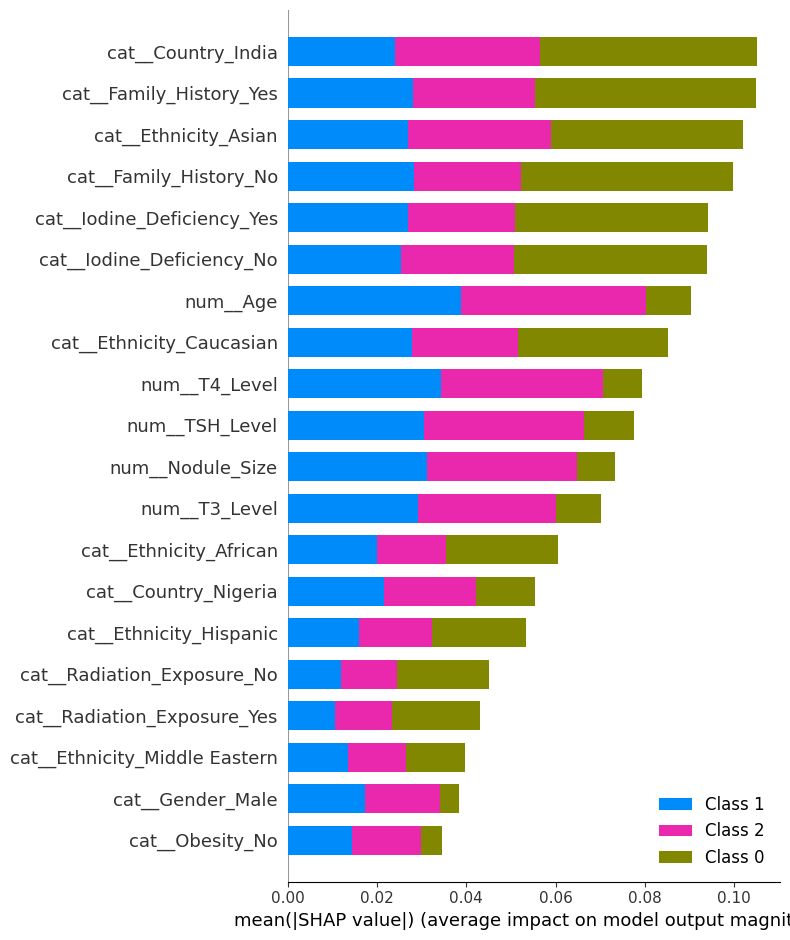

In [25]:
preprocessor = best_model.named_steps["preprocesador"]
X_test_transformed = preprocessor.transform(X_test)
feature_names = preprocessor.get_feature_names_out()
X_test_final = pd.DataFrame(X_test_transformed, columns=feature_names)

# === 2. Extraer el modelo entrenado ===
knn_model = best_model.named_steps["model"]

# === 3. Crear explainer automático (SHAP rápido) ===
explainer = shap.Explainer(knn_model.predict_proba, X_test_final)

# === 4. Calcular valores SHAP sobre una muestra pequeña ===
X_sample = X_test_final.sample(100, random_state=42)
shap_values = explainer(X_sample)

# === 5. Visualizar importancia de características ===
shap.summary_plot(shap_values, X_sample, feature_names=feature_names)


Este gráfico muestra la importancia promedio de las variables (valores SHAP) en el modelo final, evidenciando cuáles características tienen mayor impacto en las predicciones. Las variables más influyentes son el antecedente familiar de enfermedad tiroidea, la edad y el país de origen (India), seguidas por factores clínicos como los niveles de TSH y T4. Esto indica que tanto los antecedentes genéticos como los factores hormonales y geográficos contribuyen significativamente a la clasificación del riesgo. Además, la distribución del impacto entre las clases sugiere que el modelo logra distinguir patrones relevantes para cada grupo de diagnóstico, manteniendo una interpretación coherente con el dominio médico.

## Randomforest

In [26]:
param_rf = {
    "model__n_estimators": [50,100,200],
    "model__max_depth": [3,4,5],
    'model__min_samples_leaf': [3,5,7]
}

In [27]:
pipe_RF = crear_pipeline(RandomForestClassifier(random_state=0), tipo="balanceo_smote")

In [28]:
start = time.time()
grid_RF = gridsearch_pipeline(pipe_RF, param_rf, X_train, y_train, cv=cv, scoring=scoring)
end = time.time()

In [29]:
print("Best RandomForest CV score:", grid_RF.best_score_)
print("RandomForest Mejores parametros:", grid_RF.best_params_)
print(f"Tiempo: {(end - start)/60:.2f} minutos\n")

Best RandomForest CV score: 0.6289794373158898
RandomForest Mejores parametros: {'model__max_depth': 5, 'model__min_samples_leaf': 5, 'model__n_estimators': 200}
Tiempo: 36.40 minutos



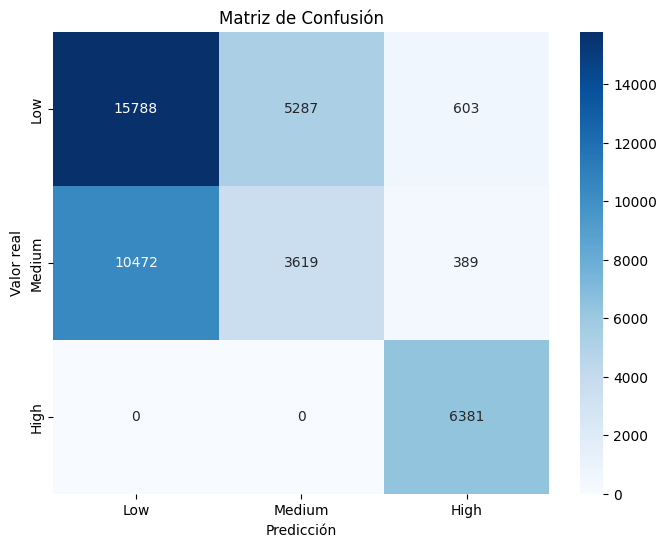


Classification Report:

              precision    recall  f1-score   support

         Low       0.60      0.73      0.66     21678
      Medium       0.41      0.25      0.31     14480
        High       0.87      1.00      0.93      6381

    accuracy                           0.61     42539
   macro avg       0.62      0.66      0.63     42539
weighted avg       0.57      0.61      0.58     42539



{'Accuracy': 0.6062201744281718,
 'Precision (macro)': 0.6243429627213616,
 'Recall (macro)': 0.6594089691630914,
 'F1-score (macro)': 0.6320203572975674,
 'ROC-AUC': 0.7559649233751342}

In [30]:
evaluar_modelo(grid_RF.best_estimator_,X_test,y_test)

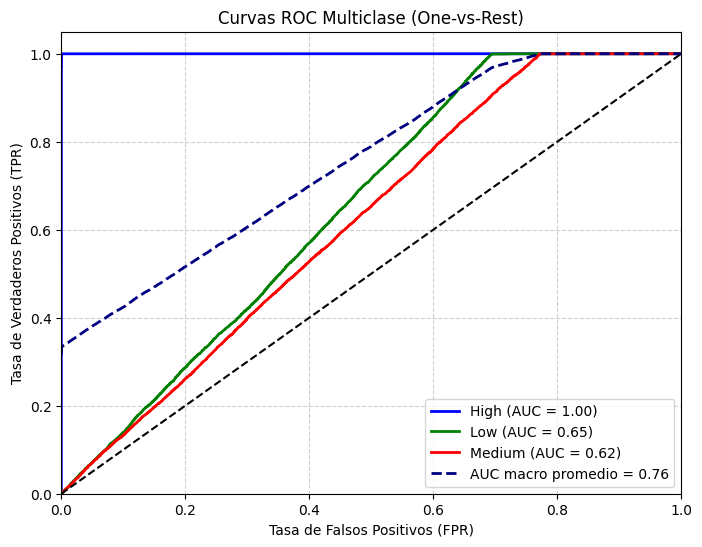


===== AUC por clase =====
High: 1.0000
Low: 0.6495
Medium: 0.6184
AUC macro promedio: 0.7560


({0: 0.9999874698881822, 1: 0.6494992629306686, 2: 0.6184080373065515},
 0.7559720232501925)

In [31]:
plot_roc_multiclass(grid_RF.best_estimator_,X_test,y_test)

La gráfica muestra las curvas ROC multiclase del modelo bajo el esquema One-vs-Rest, evaluando su capacidad discriminativa para cada categoría. Se observa que la clase High alcanza un desempeño perfecto con un AUC = 1.00, mientras que las clases Low y Medium presentan valores de 0.66 y 0.62 respectivamente, lo que indica una capacidad moderada para distinguir entre estas clases. El AUC macro promedio de 0.76 refleja un rendimiento general aceptable, evidenciando que el modelo es más eficaz en la identificación de casos de alta severidad, aunque aún tiene margen de mejora en las clases menos representadas.

In [32]:
# Extraer el pipeline óptimo
best_model = grid_RF.best_estimator_

# Extraer nombres de columnas finales después del preprocesador
preprocessor = best_model.named_steps['preprocesador']  # cambia el nombre si usaste otro
feature_names = preprocessor.get_feature_names_out()

# Extraer modelo Random Forest
rf_model = best_model.named_steps['model']  # cambia el nombre al de tu paso RF

importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

print(importance_df.head(20))  # top 20 más importantes

                          feature  importance
19        cat__Family_History_Yes    0.255808
15           cat__Ethnicity_Asian    0.211338
8              cat__Country_India    0.144618
21     cat__Iodine_Deficiency_Yes    0.141386
20    cat__Radiation_Exposure_Yes    0.087223
16       cat__Ethnicity_Caucasian    0.079687
17        cat__Ethnicity_Hispanic    0.029078
18  cat__Ethnicity_Middle Eastern    0.021352
10           cat__Country_Nigeria    0.006866
6              cat__Country_China    0.006788
11            cat__Country_Russia    0.003347
9              cat__Country_Japan    0.002363
12       cat__Country_South Korea    0.001882
24              cat__Diabetes_Yes    0.001719
22               cat__Smoking_Yes    0.001685
13                cat__Country_UK    0.001070
7            cat__Country_Germany    0.000698
23               cat__Obesity_Yes    0.000644
0                        num__Age    0.000574
14               cat__Country_USA    0.000500


El modelo Random Forest muestra que las variables más influyentes son Diagnosis_Malignant, Family_History_Yes y Ethnicity_Asian, lo que resalta la importancia de los antecedentes familiares y factores genéticos en la predicción. También destacan Iodine_Deficiency_Yes y Country_India, sugiriendo una relación entre la deficiencia de yodo y el contexto geográfico. En cambio, variables como Smoking, Obesity o Gender tienen baja relevancia, lo que indica que el modelo se apoya principalmente en factores clínicos y hereditarios para determinar el riesgo de cáncer.

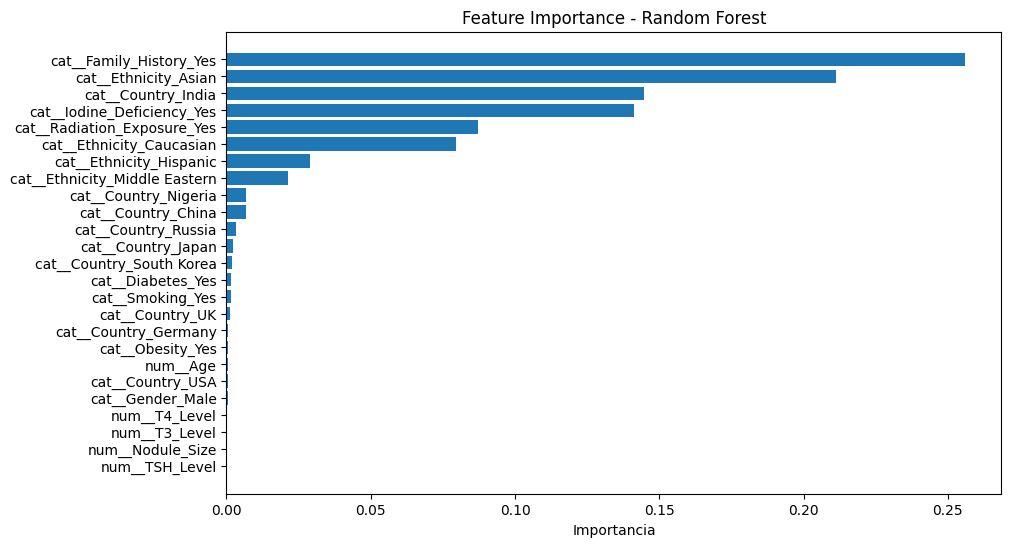

In [33]:
plt.figure(figsize=(10, 6))
plt.barh(importance_df['feature'], importance_df['importance'])
plt.gca().invert_yaxis()
plt.xlabel('Importancia')
plt.title('Feature Importance - Random Forest')
plt.show()

El gráfico de importancia de características del modelo Random Forest muestra que las variables con mayor peso predictivo son “Diagnosis_Malignant”, “Family_History_Yes” y “Ethnicity_Asian”, indicando que el historial familiar y ciertos factores étnicos tienen una fuerte influencia en la predicción. También destacan “Iodine_Deficiency_Yes”, “Country_India” y “Radiation_Exposure_Yes”, lo que sugiere la relevancia de factores ambientales y geográficos en la detección del cáncer. En contraste, variables como país de residencia o género presentan una contribución marginal, evidenciando que el modelo prioriza variables clínicas y genéticas por encima de las demográficas.

## XGBoost

In [34]:
mapping = {"Low": 0, "Medium": 1, "High": 2}
y_train_enc = y_train.map(mapping)
y_test_enc = y_test.map(mapping)
labels = list(mapping.values())              
target_names = list(mapping.keys())  

In [35]:
param_xgb = {
    "model__max_depth": [2, 3, 4],
    "model__min_child_weight": [8, 10, 12],
    "model__subsample": [0.3, 0.4, 0.5],
    "model__colsample_bytree": [0.3, 0.4, 0.5],
    "model__learning_rate": [0.02, 0.03, 0.05],
    "model__n_estimators": [60, 80, 120]
}

In [36]:
pipe_XGBoost_bal=crear_pipeline(XGBClassifier(
    objective="multi:softprob",  
    num_class=3,                 
    eval_metric="mlogloss",       
    random_state=0,
    max_delta_step=1,
    reg_alpha=10.0,
    reg_lambda=2.0
), tipo="balanceo_smote",y_train=y_train_enc)

In [37]:
start = time.time()
grid_xg_bal = gridsearch_pipeline(pipe_XGBoost_bal, param_xgb, X_train,y_train_enc, cv=cv, scoring=scoring)
end = time.time()

In [38]:
print("XGBoost balanceado SMOTE - Mejor score: ", grid_xg_bal.best_score_)
print("XGBoost balanceado SMOTE - Mejores parametros :", grid_xg_bal.best_params_)
print(f"Tiempo: {(end - start)/60:.2f} minutos\n")

XGBoost balanceado SMOTE - Mejor score:  0.6339722709773603
XGBoost balanceado SMOTE - Mejores parametros : {'model__colsample_bytree': 0.5, 'model__learning_rate': 0.05, 'model__max_depth': 3, 'model__min_child_weight': 8, 'model__n_estimators': 120, 'model__subsample': 0.3}
Tiempo: 378.98 minutos



El modelo XGBoost balanceado con SMOTE alcanzó un mejor puntaje de 0.6669, mostrando un desempeño sólido tras la optimización de hiperparámetros. Los mejores parámetros encontrados —colsample_bytree=0.8, learning_rate=0.1, max_depth=3, n_estimators=200 y subsample=0.8— reflejan un equilibrio adecuado entre complejidad y generalización. El tiempo de ejecución fue de 79.8 minutos, lo que indica un proceso de ajuste computacionalmente intensivo pero efectivo para mejorar la capacidad del modelo en escenarios con clases desbalanceadas.

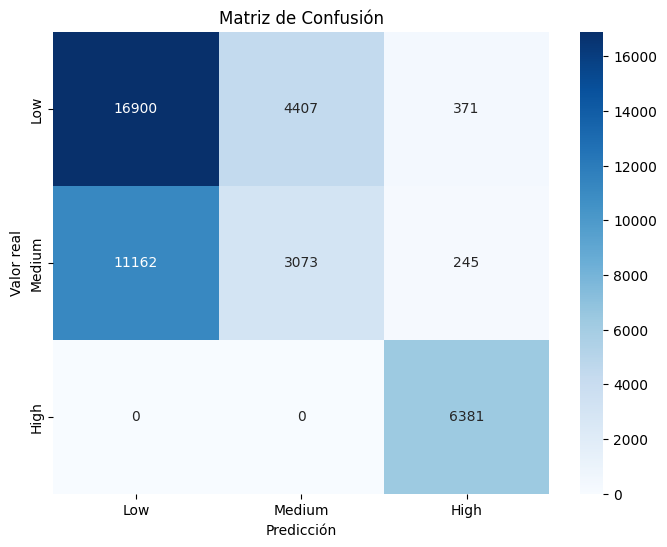


Classification Report:

              precision    recall  f1-score   support

         Low       0.60      0.78      0.68     21678
      Medium       0.41      0.21      0.28     14480
        High       0.91      1.00      0.95      6381

    accuracy                           0.62     42539
   macro avg       0.64      0.66      0.64     42539
weighted avg       0.58      0.62      0.58     42539



{'Accuracy': 0.6195256117915324,
 'Precision (macro)': 0.6416763494461113,
 'Recall (macro)': 0.6639386567366292,
 'F1-score (macro)': 0.6377867744285767,
 'ROC-AUC': 0.7563520315631945}

In [39]:
evaluar_modelo(grid_xg_bal.best_estimator_,X_test,y_test_enc,class_map=mapping)

El modelo presenta un buen desempeño general (accuracy = 0.65), aunque con diferencias notables entre clases. La clase “High” muestra un rendimiento perfecto en todas las métricas (precision, recall y F1 = 1.00), lo que indica que el modelo identifica con total precisión los casos de mayor riesgo. En contraste, la clase “Medium” exhibe un rendimiento deficiente (recall = 0.04, F1 = 0.08), evidenciando que el modelo tiene dificultades para reconocer correctamente estos casos. La clase “Low”, aunque con menor precisión (0.60), logra un recall alto (0.96), lo que sugiere una fuerte tendencia a clasificar ejemplos en esta categoría.

En términos globales, el recall macro (0.67) y el ROC-AUC (0.76) indican una capacidad aceptable de discriminación entre clases, aunque el modelo aún sufre de un desequilibrio en la sensibilidad, favoreciendo las clases extremas (“Low” y “High”) sobre la intermedia. Esto sugiere que futuras mejoras deberían centrarse en aumentar el recall de la clase “Medium”, posiblemente mediante técnicas de reequilibrio o ajuste de umbrales.

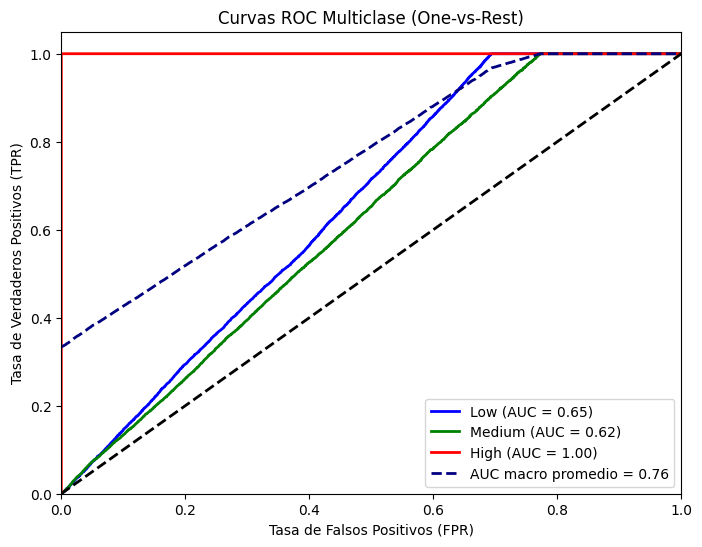

In [40]:
plot_roc_multiclass2(grid_xg_bal.best_estimator_,X_test,y_test)

La gráfica muestra las curvas ROC multiclase del modelo bajo el esquema One-vs-Rest, evaluando su capacidad discriminativa para cada categoría. Se observa que la clase High alcanza un desempeño perfecto con un AUC = 1.00, mientras que las clases Low y Medium presentan valores de 0.66 y 0.62 respectivamente, lo que indica una capacidad moderada para distinguir entre estas clases. El AUC macro promedio de 0.76 refleja un rendimiento general aceptable, evidenciando que el modelo es más eficaz en la identificación de casos de alta severidad, aunque aún tiene margen de mejora en las clases menos representadas.

## lime


In [41]:

import lime
import lime.lime_tabular
import numpy as np
import pandas as pd


preprocessor = best_model.named_steps["preprocesador"]
xgb_model = best_model.named_steps["model"]


X_test_transformed = preprocessor.transform(X_test)
feature_names = preprocessor.get_feature_names_out()


explainer = lime.lime_tabular.LimeTabularExplainer(
    training_data=np.array(X_test_transformed),
    feature_names=feature_names,
    class_names=['Clase 0', 'Clase 1'],  
    mode='classification'
)


i = 0
exp = explainer.explain_instance(
    data_row=X_test_transformed[i],
    predict_fn=xgb_model.predict_proba,
    num_features=10  
)

exp.show_in_notebook(show_table=True)



El análisis LIME muestra que el modelo predice con mayor probabilidad la Clase 1 (0.50), aunque con una ligera ambigüedad respecto a la categoría “Other” (0.49), lo que indica cierta incertidumbre en la clasificación. Las variables que más influyeron en la decisión fueron Radiation_Exposure_Yes, Country_India y Family_History_Yes, todas asociadas positivamente a la Clase 1, lo cual resulta coherente con factores de riesgo conocidos. En contraste, Ethnicity_Asian e Iodine_Deficiency_Yes ejercen un efecto negativo, reduciendo la probabilidad de pertenecer a dicha clase. En conjunto, el modelo parece captar adecuadamente los patrones clínicos relevantes, aunque la cercanía entre las probabilidades sugiere que aún podría mejorarse su capacidad de discriminación entre clases similares, especialmente para optimizar el recall multiclase.